# 01. 프로젝트 환경 및 데이터 구조 확인

AI-Hub 「한국인 감정인식을 위한 복합 영상」 샘플 데이터를 활용하여  
라벨링 JSON 구조와 원천 이미지의 연결 관계를 확인하고,  
얼굴 bounding box를 이용한 전처리 가능 여부를 검증한다.

## 1. 라벨링 JSON 파일 불러오기

기쁨 클래스의 라벨링 JSON 파일을 불러오고,
전체 데이터 구조가 어떤 형태인지 확인한다.

In [2]:
import json # JSON 파일을 읽기 위해 json 모듈 불러오기
from pathlib import Path # 파일 경로를 편하게 다루기 위해 Path 불러오기

In [3]:
# 기쁨 클래스 라벨링 JSON 파일 경로 지정
json_path = Path(
    "../02_data/sample/라벨링데이터/EMOIMG_기쁨_SAMPLE/img_emotion_training_data(기쁨).json"
)

# JSON 파일 열기
# utf-8 인코딩을 사용해 한글이 깨지지 않도록 함
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

## 2. JSON 기본 구조 확인

JSON의 최상위 자료형과 데이터 개수, 첫 번째 항목의 구성 요소를 확인한다.

각 이미지에는 파일명, 성별, 나이, 감정 정보와 함께
3명의 어노테이터(annot_A, annot_B, annot_C)의 라벨링 결과가 포함되어 있다.

In [4]:
type(data) # JSON 전체 구조 확인

list

In [5]:
len(data) # JSON 안에 들어 있는 데이터 개수 확인

60103

In [6]:
data[0] # 첫 번째 데이터 확인

{'filename': '5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf54dcd7a2c4508588ff3_여_30_기쁨_공공시설&종교&의료시설_20201204105732-001-007.jpg',
 'gender': '여',
 'age': 30,
 'isProf': '전문인',
 'faceExp_uploader': '기쁨',
 'bg_uploader': '공공시설/종교/의료시설',
 'annot_A': {'boxes': {'maxX': 1912.2253,
   'maxY': 1581.6027,
   'minX': 1187.4949,
   'minY': 579.22235},
  'faceExp': '기쁨',
  'bg': '공공시설/종교/의료'},
 'annot_B': {'boxes': {'maxX': 1912.348108621648,
   'maxY': 1572.1522585800617,
   'minX': 1206.363701502596,
   'minY': 579.1777983055337},
  'faceExp': '기쁨',
  'bg': '공공시설/종교/의료'},
 'annot_C': {'boxes': {'maxX': 1890.909447114109,
   'maxY': 1567.448627450284,
   'minX': 1183.8414475546967,
   'minY': 596.9434661684523},
  'faceExp': '기쁨',
  'bg': '공공시설/종교/의료'}}

In [7]:
data[0].keys() # 첫 번째 데이터가 가지고 있는 key 목록 확인

dict_keys(['filename', 'gender', 'age', 'isProf', 'faceExp_uploader', 'bg_uploader', 'annot_A', 'annot_B', 'annot_C'])

## 3. 감정 라벨 및 어노테이션 정보 확인

각 이미지에는 업로더가 기록한 감정 정보와
3명의 어노테이터가 판정한 감정 정보가 포함되어 있다.

또한 각 어노테이터는 얼굴 영역을 bounding box 좌표로 표시하였다.

In [8]:
# 업로더가 지정한 감정 라벨 확인
data[0]['faceExp_uploader']

'기쁨'

In [9]:
# 세 어노테이터가 각각 판정한 감정 확인
data[0]['annot_A']['faceExp']
data[0]['annot_B']['faceExp']
data[0]['annot_C']['faceExp']

'기쁨'

In [10]:
# annot_A가 지정한 얼굴 bounding box 좌표 확인
data[0]['annot_A']['boxes']

{'maxX': 1912.2253, 'maxY': 1581.6027, 'minX': 1187.4949, 'minY': 579.22235}

## 4. 라벨링 데이터와 원천 이미지 매칭 확인

JSON의 `filename` 값을 기준으로 실제 원천 이미지와
라벨링 정보가 연결되는지 확인한다.

샘플 데이터에서는 JSON 전체 데이터 중 일부 이미지만
원천데이터로 제공되고 있는지 함께 확인한다.

In [11]:
data[0]['filename']

'5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf54dcd7a2c4508588ff3_여_30_기쁨_공공시설&종교&의료시설_20201204105732-001-007.jpg'

In [12]:
from pathlib import Path

filename = data[0]['filename']

image_path = Path(
    "../02_data/sample/원천데이터/EMOIMG_기쁨_SAMPLE"
) / filename

image_path.exists()

False

In [13]:
from pathlib import Path

# 기쁨 샘플 원천 이미지 폴더 경로 지정
source_dir = Path(
    "../02_data/sample/원천데이터/EMOIMG_기쁨_SAMPLE"
)

files = list(source_dir.iterdir()) # 해당 폴더 안에 있는 파일 목록 불러오기

len(files), files[:5]

(389,
 [WindowsPath('../02_data/sample/원천데이터/EMOIMG_기쁨_SAMPLE/02dfd7b7659985e625f9fe8824d64569264ca48b2913efe0c20c8af0a4a3a017_남_30_기쁨_행사&사무공간_20210222180236-006-001.jpg'),
  WindowsPath('../02_data/sample/원천데이터/EMOIMG_기쁨_SAMPLE/08c0d9389dbc222023035a3ef6ad78ff04b107aa756b0c228f2455ead387942e_여_20_기쁨_공공시설&종교&의료시설_20210208201331-001-001.jpg'),
  WindowsPath('../02_data/sample/원천데이터/EMOIMG_기쁨_SAMPLE/08c0d9389dbc222023035a3ef6ad78ff04b107aa756b0c228f2455ead387942e_여_20_기쁨_상업시설&점포&시장_20210208201414-003-001.jpg'),
  WindowsPath('../02_data/sample/원천데이터/EMOIMG_기쁨_SAMPLE/08c0d9389dbc222023035a3ef6ad78ff04b107aa756b0c228f2455ead387942e_여_20_기쁨_상업시설&점포&시장_20210208201414-003-002.jpg'),
  WindowsPath('../02_data/sample/원천데이터/EMOIMG_기쁨_SAMPLE/08c0d9389dbc222023035a3ef6ad78ff04b107aa756b0c228f2455ead387942e_여_20_기쁨_상업시설&점포&시장_20210208201414-003-003.jpg')])

### 개별 파일 매칭 확인

JSON의 첫 번째 항목(`data[0]`)은 샘플 원천데이터에 존재하지 않았다.
따라서 JSON 전체와 샘플 원천 이미지의 파일명 집합을 비교하여
실제로 대응되는 데이터 범위를 확인한다.

In [14]:
files[0].name

'02dfd7b7659985e625f9fe8824d64569264ca48b2913efe0c20c8af0a4a3a017_남_30_기쁨_행사&사무공간_20210222180236-006-001.jpg'

In [15]:
print("JSON filename:")
print(data[0]['filename'])

print("\n실제 첫 파일:")
print(files[0].name)

JSON filename:
5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf54dcd7a2c4508588ff3_여_30_기쁨_공공시설&종교&의료시설_20201204105732-001-007.jpg

실제 첫 파일:
02dfd7b7659985e625f9fe8824d64569264ca48b2913efe0c20c8af0a4a3a017_남_30_기쁨_행사&사무공간_20210222180236-006-001.jpg


In [16]:
target_name = data[0]['filename']

target_name in [f.name for f in files]

False

In [17]:
from pathlib import Path

target_name = data[0]['filename']

matches = list(
    Path("../02_data/sample/원천데이터").rglob(target_name)
)

matches

[]

In [18]:
source_dir = Path(
    "../02_data/sample/원천데이터/EMOIMG_기쁨_SAMPLE"
)

# 폴더 안 실제 파일명만 set 형태로 저장
# set을 사용하면 파일명 포함 여부를 빠르게 확인할 수 있음
image_names = {f.name for f in source_dir.iterdir() if f.is_file()}

json_names = {item['filename'] for item in data} # JSON 안의 모든 filename을 set 형태로 저장

print("JSON 데이터 수:", len(json_names)) # JSON 데이터 수 확인
print("원천 이미지 수:", len(image_names)) # 실제 샘플 이미지 수 확인
print("일치하는 파일 수:", len(json_names & image_names)) # JSON과 실제 이미지 양쪽에 모두 존재하는 파일 수 확인
print("JSON에만 있는 파일 수:", len(json_names - image_names)) # JSON에는 있지만 샘플 원천 이미지에는 없는 파일 수 확인
print("이미지에만 있는 파일 수:", len(image_names - json_names)) # 샘플 원천 이미지에는 있지만 JSON에는 없는 파일 수 확인

JSON 데이터 수: 60103
원천 이미지 수: 389
일치하는 파일 수: 389
JSON에만 있는 파일 수: 59714
이미지에만 있는 파일 수: 0


### 확인 결과

- JSON 데이터 수: 60,103건
- 샘플 원천 이미지 수: 389장
- JSON과 일치하는 이미지 수: 389장
- 이미지에만 존재하는 파일: 0장

따라서 샘플 원천 이미지 389장은 모두 JSON 라벨링 정보와 정상적으로 연결되며,
JSON에는 샘플보다 더 많은 전체 라벨링 정보가 포함되어 있음을 확인하였다.

## 5. 실제 샘플 이미지에 대응되는 라벨만 추출

JSON 전체 데이터 중 실제 샘플 원천 이미지와 대응되는 항목만 추출하여
향후 전처리와 EDA에 사용할 데이터로 구성한다.

In [19]:
# JSON 전체 데이터 중 실제 샘플 이미지가 존재하는 항목만 추출
matched_data = [
    item for item in data
    if item['filename'] in image_names
]

len(matched_data) # 실제 매칭된 데이터 개수 확인

389

총 389개의 샘플 이미지와 대응되는 라벨 데이터를 추출하였다.

In [20]:
matched_data[0]

{'filename': '6d88d862df110f113ce1fe29de6e61f87f40c942ca530a3ae0c61a463ffcda93_여_10_기쁨_공공시설&종교&의료시설_20210209150834-001-003.jpg',
 'gender': '여',
 'age': 10,
 'isProf': '일반인',
 'faceExp_uploader': '기쁨',
 'bg_uploader': '공공시설/종교/의료시설',
 'annot_A': {'boxes': {'maxX': 1135.707812,
   'maxY': 818.5077252,
   'minX': 684.189012,
   'minY': 271.00124519999997},
  'faceExp': '기쁨',
  'bg': '공공시설/종교/의료시설'},
 'annot_B': {'boxes': {'maxX': 1140.134812,
   'maxY': 819.3387252,
   'minX': 687.497012,
   'minY': 269.7602452},
  'faceExp': '기쁨',
  'bg': '공공시설/종교/의료시설'},
 'annot_C': {'boxes': {'maxX': 1142.875812,
   'maxY': 815.7457252,
   'minX': 682.6680120000001,
   'minY': 262.28524519999996},
  'faceExp': '기쁨',
  'bg': '공공시설/종교/의료시설'}}

In [21]:
matched_data[0]['filename']

'6d88d862df110f113ce1fe29de6e61f87f40c942ca530a3ae0c61a463ffcda93_여_10_기쁨_공공시설&종교&의료시설_20210209150834-001-003.jpg'

In [22]:
filename = matched_data[0]['filename']

image_path = source_dir / filename

image_path.exists()

True

## 6. 이미지 파일명 기반 라벨 조회 구조 생성

이미지 파일명을 key로 사용하여 해당 이미지의 라벨링 정보를
빠르게 조회할 수 있도록 dictionary를 생성한다.

In [23]:
# filename을 key로 사용하고,
# 해당 이미지의 전체 JSON 정보를 value로 저장하는 dictionary 생성
label_dict = {
    item['filename']: item
    for item in data
}

In [24]:
# 원천데이터 폴더의 첫 번째 이미지 파일명 가져오기
filename = files[0].name

label_info = label_dict[filename] # 해당 파일명의 JSON 라벨 정보 조회

In [25]:
label_info['faceExp_uploader'] # 업로더 감정 확인

'기쁨'

In [26]:
label_info['annot_A']['faceExp'] # annot_A 감정 확인

'기쁨'

In [27]:
label_info['annot_A']['boxes'] # annot_A 얼굴 bounding box 확인

{'maxX': 763.4695115,
 'maxY': 751.5649399,
 'minX': 440.09466150000003,
 'minY': 356.8849299}

In [28]:
print("매칭 데이터 수:", len(matched_data))

filename = matched_data[0]['filename']
image_path = source_dir / filename

print("파일명:", filename)
print("실제 이미지 존재:", image_path.exists())
print("감정:", matched_data[0]['faceExp_uploader'])
print("Bounding Box:", matched_data[0]['annot_A']['boxes'])

매칭 데이터 수: 389
파일명: 6d88d862df110f113ce1fe29de6e61f87f40c942ca530a3ae0c61a463ffcda93_여_10_기쁨_공공시설&종교&의료시설_20210209150834-001-003.jpg
실제 이미지 존재: True
감정: 기쁨
Bounding Box: {'maxX': 1135.707812, 'maxY': 818.5077252, 'minX': 684.189012, 'minY': 271.00124519999997}


## 7. 한글 파일 경로 이미지 로딩 확인

Windows 환경에서 한글이 포함된 파일명을 `cv2.imread()`로 읽었을 때
이미지가 정상적으로 로드되지 않는 문제가 발생하였다.

따라서 `numpy.fromfile()`과 `cv2.imdecode()`를 사용하여
한글 경로에서도 이미지를 안정적으로 불러오도록 처리하였다.

In [29]:
import cv2 # 이미지 처리를 위한 OpenCV
print(image_path)
print(image_path.exists())

image = cv2.imread(str(image_path)) # cv2.imread()로 한글 경로 이미지를 읽을 수 있는지 확인
print(image)

..\02_data\sample\원천데이터\EMOIMG_기쁨_SAMPLE\6d88d862df110f113ce1fe29de6e61f87f40c942ca530a3ae0c61a463ffcda93_여_10_기쁨_공공시설&종교&의료시설_20210209150834-001-003.jpg
True
None


In [30]:
import numpy as np # 파일을 바이너리 배열로 읽기 위한 NumPy
import matplotlib.pyplot as plt # 이미지 출력용 Matplotlib

# 한글이 포함된 파일 경로를 바이너리 데이터로 읽음
image_array = np.fromfile(str(image_path), dtype=np.uint8)

# 바이너리 배열을 OpenCV 이미지로 디코딩
# cv2.imread()가 한글 경로를 읽지 못하는 문제를 피하기 위한 방식
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

print(image is None) # 이미지가 정상적으로 로드되었는지 확인

False


In [31]:
# OpenCV는 기본적으로 BGR 순서를 사용함
# Matplotlib은 RGB 순서를 사용하므로 색상 순서를 변환
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

## 8. 얼굴 Bounding Box 시각화

JSON에 포함된 `annot_A`의 bounding box 좌표를 이용해
실제 이미지에서 얼굴 영역이 정상적으로 표시되는지 확인한다.

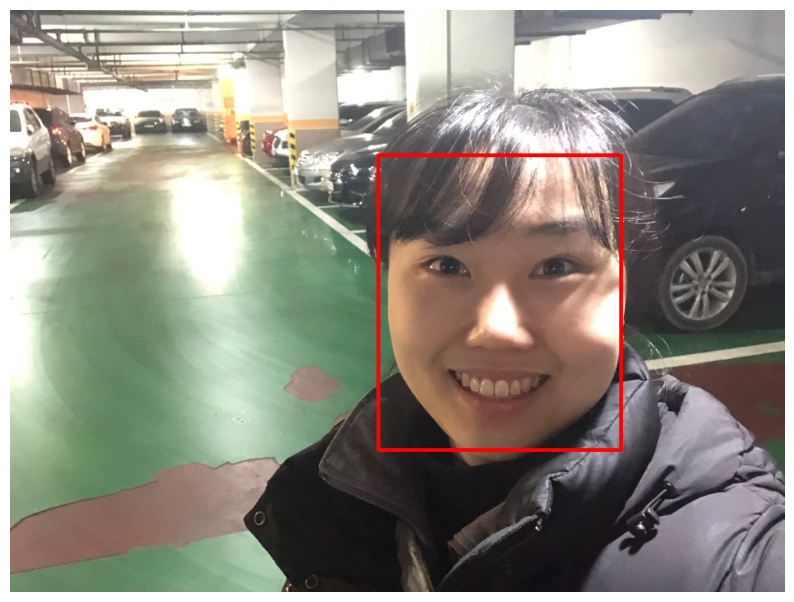

In [32]:
box = matched_data[0]['annot_A']['boxes'] # annot_A의 얼굴 bounding box 좌표 가져오기

# OpenCV 좌표 계산에 사용하기 위해 실수형 좌표를 정수형으로 변환
min_x = int(box['minX'])
min_y = int(box['minY'])
max_x = int(box['maxX'])
max_y = int(box['maxY'])

image_box = image_rgb.copy() # 원본 이미지가 변경되지 않도록 복사본 생성

# 얼굴 영역에 사각형 그리기
cv2.rectangle(
    image_box, 
    (min_x, min_y),  # 왼쪽 위 좌표
    (max_x, max_y),   # 오른쪽 아래 좌표
    (255, 0, 0),  # RGB 기준 빨간색
    5  # 선 두께
)

# bounding box가 표시된 이미지 출력
plt.figure(figsize=(10, 8))
plt.imshow(image_box)
plt.axis('off')
plt.show()

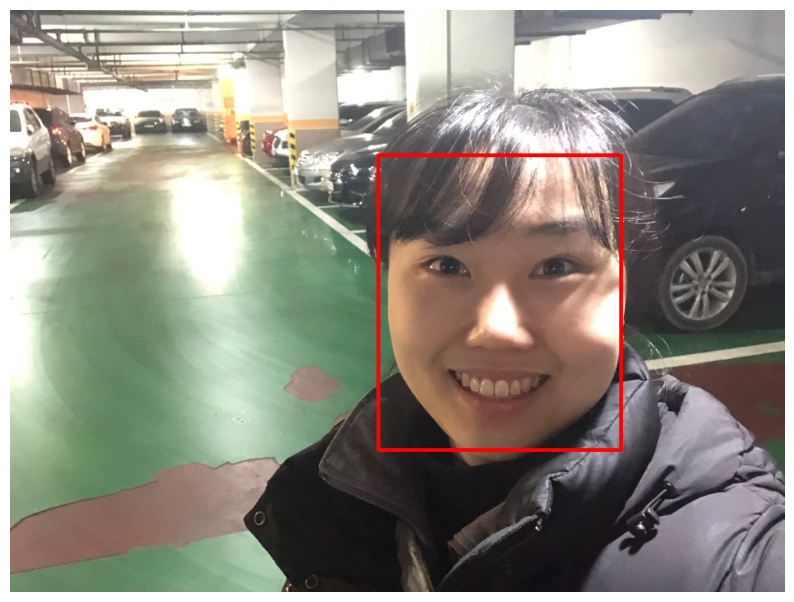

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 읽기
image_array = np.fromfile(str(image_path), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# BGR → RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# bounding box
box = matched_data[0]['annot_A']['boxes']

min_x = int(box['minX'])
min_y = int(box['minY'])
max_x = int(box['maxX'])
max_y = int(box['maxY'])

# 원본 보존
image_box = image_rgb.copy()

# bounding box 그리기
cv2.rectangle(
    image_box,
    (min_x, min_y),
    (max_x, max_y),
    (255, 0, 0),
    5
)

plt.figure(figsize=(10, 8))
plt.imshow(image_box)
plt.axis('off')
plt.show()

## 9. 얼굴 영역 Crop 확인

Bounding box 좌표를 이용하여 원본 이미지에서 얼굴 영역만 추출한다.

감정 분류 모델은 배경보다 얼굴 표정 정보가 중요하므로,
향후 학습 데이터는 얼굴 영역 중심으로 전처리할 예정이다.

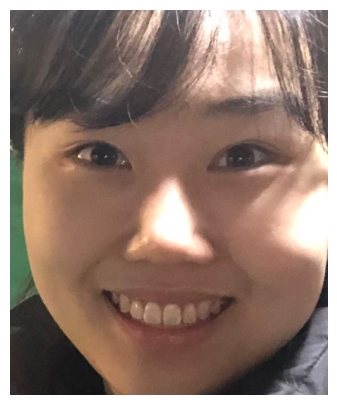

In [34]:
# bounding box 좌표를 사용해 얼굴 영역만 잘라냄
# NumPy 이미지 배열은 [y범위, x범위] 순서로 슬라이싱함
face = image_rgb[min_y:max_y, min_x:max_x]

# 잘라낸 얼굴 이미지 출력
plt.figure(figsize=(5, 5))
plt.imshow(face)
plt.axis('off')
plt.show()

d:\emotion_recognition_project\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\emotion_recognition_project\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


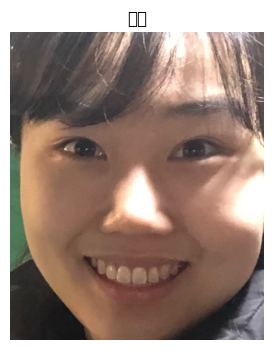

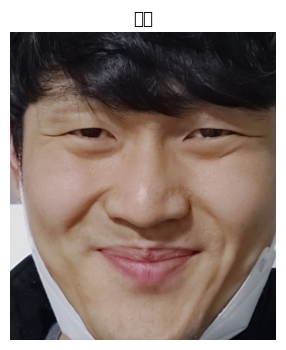

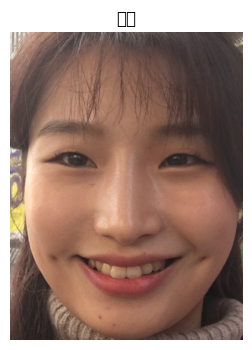

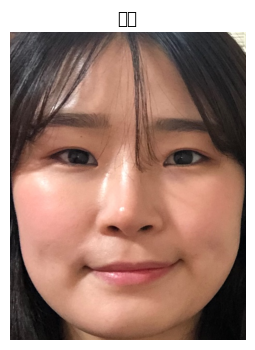

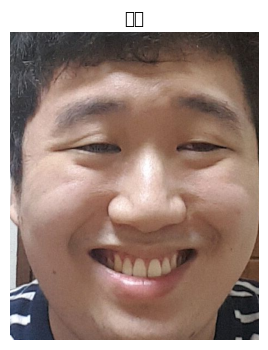

In [35]:
for i in range(5):
    item = matched_data[i] 
    filename = item['filename']
    image_path = source_dir / filename

    image_array = np.fromfile(str(image_path), dtype=np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    box = item['annot_A']['boxes']

    # 세 어노테이터의 bounding box 가져오기
    min_x = int(box['minX'])
    min_y = int(box['minY'])
    max_x = int(box['maxX'])
    max_y = int(box['maxY'])

    face = image_rgb[min_y:max_y, min_x:max_x]

    plt.figure(figsize=(4, 4))
    plt.imshow(face)
    plt.title(item['faceExp_uploader'])
    plt.axis('off')
    plt.show()

## 10. 어노테이터별 Bounding Box 비교

동일한 이미지에 대해 annot_A, annot_B, annot_C가 지정한
얼굴 bounding box가 얼마나 차이가 나는지 비교한다.

여러 샘플 이미지를 확인하여 특정 어노테이터의 좌표를
대표 bounding box로 사용할 수 있는지 검토한다.

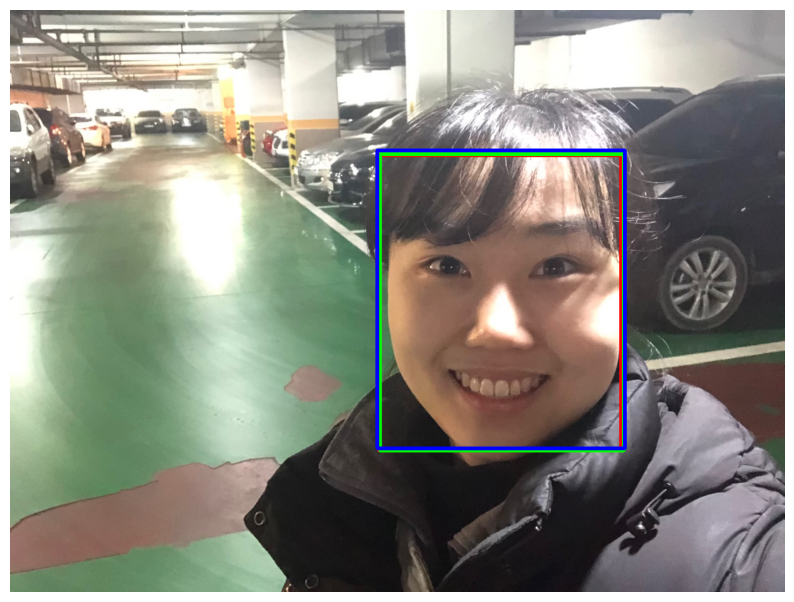

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

item = matched_data[0] # 비교할 이미지 하나 선택

filename = item['filename']
image_path = source_dir / filename

# 한글 경로 이미지 읽기
image_array = np.fromfile(str(image_path), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 원본 보존
image_compare = image_rgb.copy()

# 세 어노테이터의 bounding box 가져오기
box_a = item['annot_A']['boxes']
box_b = item['annot_B']['boxes']
box_c = item['annot_C']['boxes']

# 각각 (minX, minY, maxX, maxY) 형태로 정리
a = (
    int(box_a['minX']), int(box_a['minY']),
    int(box_a['maxX']), int(box_a['maxY'])
)

b = (
    int(box_b['minX']), int(box_b['minY']),
    int(box_b['maxX']), int(box_b['maxY'])
)

c = (
    int(box_c['minX']), int(box_c['minY']),
    int(box_c['maxX']), int(box_c['maxY'])
)

# 박스 그리기
cv2.rectangle(
    image_compare,
    (a[0], a[1]),
    (a[2], a[3]),
    (255, 0, 0),
    5
)

cv2.rectangle(
    image_compare,
    (b[0], b[1]),
    (b[2], b[3]),
    (0, 255, 0),
    5
)

cv2.rectangle(
    image_compare,
    (c[0], c[1]),
    (c[2], c[3]),
    (0, 0, 255),
    5
)

plt.figure(figsize=(10, 8))
plt.imshow(image_compare)
plt.axis('off')
plt.show()

In [37]:
# 좌표 비교
print("annot_A:", a)
print("annot_B:", b)
print("annot_C:", c)

annot_A: (684, 271, 1135, 818)
annot_B: (687, 269, 1140, 819)
annot_C: (682, 262, 1142, 815)


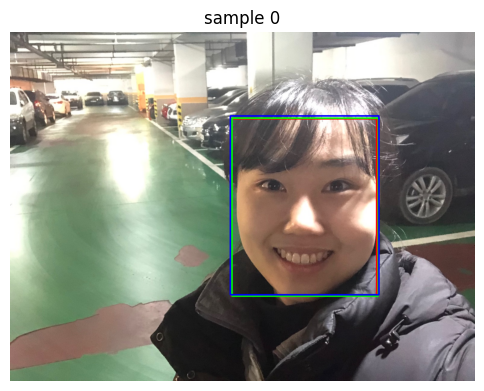

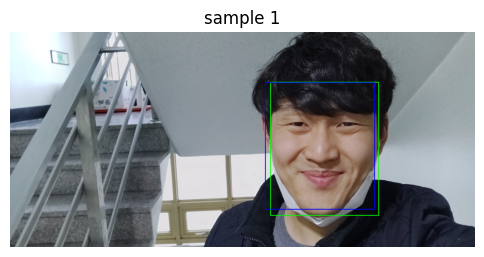

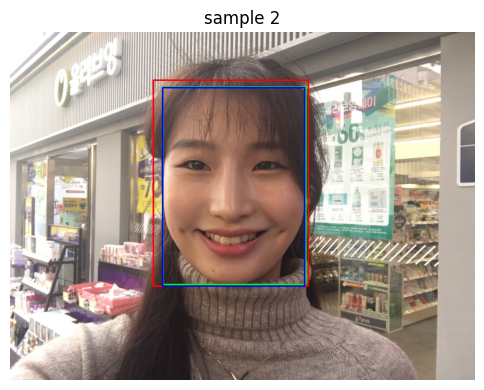

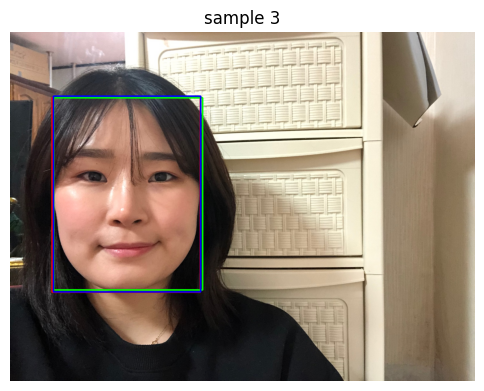

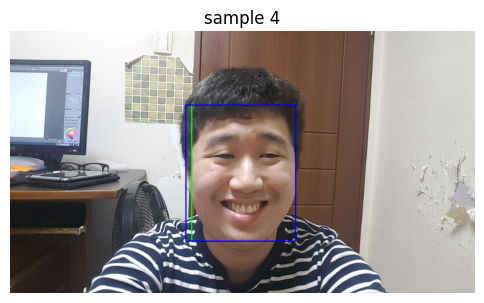

In [38]:
for i in range(5):
    item = matched_data[i]

    filename = item['filename']
    image_path = source_dir / filename

    image_array = np.fromfile(str(image_path), dtype=np.uint8)
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    image_compare = image_rgb.copy()

    for annot, color in [
        ('annot_A', (255, 0, 0)),
        ('annot_B', (0, 255, 0)),
        ('annot_C', (0, 0, 255))
    ]:
        box = item[annot]['boxes']

        min_x = int(box['minX'])
        min_y = int(box['minY'])
        max_x = int(box['maxX'])
        max_y = int(box['maxY'])

        cv2.rectangle(
            image_compare,
            (min_x, min_y),
            (max_x, max_y),
            color,
            4
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(image_compare)
    plt.title(f"sample {i}")
    plt.axis('off')
    plt.show()

### 비교 결과

예시 이미지의 bounding box 좌표는 다음과 같았다.

- annot_A: (684, 271, 1135, 818)
- annot_B: (687, 269, 1140, 819)
- annot_C: (682, 262, 1142, 815)

추가로 5장의 샘플 이미지를 비교한 결과,
세 어노테이터의 bounding box가 대부분 겹치는 것을 확인하였다.

따라서 현재 샘플 데이터에서는 어노테이터 간 얼굴 영역 판단 차이가 크지 않으며,
전처리 단순화를 위해 `annot_A`의 bounding box를 대표 좌표로 사용하는 방안을 고려한다.

## 11. 샘플 전처리용 DataFrame 생성

샘플 원천 이미지와 매칭된 JSON 정보를 이용하여
EDA 및 얼굴 이미지 전처리 가능성을 확인하기 위한 DataFrame을 생성한다.

이번 DataFrame은 본 학습용 데이터가 아니라,
샘플 데이터 구조와 전처리 과정을 검증하기 위한 용도이다.

주요 컬럼은 다음과 같다.

- 이미지 파일명
- 성별
- 나이
- 전문인 여부
- 업로더 감정
- 어노테이터별 감정
- 얼굴 bounding box 좌표
- 실제 이미지 경로

In [39]:
import pandas as pd # DataFrame 생성을 위해 pandas 불러오기

rows = [] # 각 이미지의 정보를 한 행씩 담을 리스트 생성

# 실제 샘플 이미지와 매칭된 JSON 데이터 순회
for item in matched_data:
    box = item['annot_A']['boxes'] # 얼굴 crop에는 annot_A의 bounding box를 사용

    # 이미지 한 장의 정보를 dictionary 형태로 저장
    rows.append({
        'filename': item['filename'], # 이미지 파일명
        'gender': item['gender'], # 성별
        'age': item['age'], # 나이
        'isProf': item['isProf'], # 전문인 여부
        'faceExp_uploader': item['faceExp_uploader'], # 업로더가 지정한 감정

        # 어노테이터별 감정
        'annot_A_faceExp': item['annot_A']['faceExp'],
        'annot_B_faceExp': item['annot_B']['faceExp'],
        'annot_C_faceExp': item['annot_C']['faceExp'],

         # annot_A의 얼굴 bounding box 좌표
        'minX': box['minX'],
        'minY': box['minY'],
        'maxX': box['maxX'],
        'maxY': box['maxY'],

        # 실제 이미지 파일 경로
        'image_path': str(source_dir / item['filename'])
    })

sample_df = pd.DataFrame(rows) # 리스트에 저장한 정보를 DataFrame으로 변환

In [40]:
sample_df.shape # 상위 5개 행 확인

(389, 13)

In [41]:
sample_df.info() # 행과 열 개수 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389 entries, 0 to 388
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   filename          389 non-null    object 
 1   gender            389 non-null    object 
 2   age               389 non-null    int64  
 3   isProf            389 non-null    object 
 4   faceExp_uploader  389 non-null    object 
 5   annot_A_faceExp   389 non-null    object 
 6   annot_B_faceExp   389 non-null    object 
 7   annot_C_faceExp   389 non-null    object 
 8   minX              389 non-null    float64
 9   minY              389 non-null    float64
 10  maxX              389 non-null    float64
 11  maxY              389 non-null    float64
 12  image_path        389 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 39.6+ KB


In [42]:
sample_df.columns # 컬럼별 자료형, 결측치 여부 확인

Index(['filename', 'gender', 'age', 'isProf', 'faceExp_uploader',
       'annot_A_faceExp', 'annot_B_faceExp', 'annot_C_faceExp', 'minX', 'minY',
       'maxX', 'maxY', 'image_path'],
      dtype='object')

## 12. 샘플 DataFrame 기본 품질 점검

생성한 샘플 DataFrame에 대해
결측치, 중복 데이터, 어노테이터 간 감정 라벨 일치 여부를 확인한다.

이를 통해 본 데이터 전처리 시 적용할
데이터 정제 기준을 사전에 검토한다.

In [43]:
sample_df.isnull().sum() # 컬럼별 결측치 개수 확인

filename            0
gender              0
age                 0
isProf              0
faceExp_uploader    0
annot_A_faceExp     0
annot_B_faceExp     0
annot_C_faceExp     0
minX                0
minY                0
maxX                0
maxY                0
image_path          0
dtype: int64

In [44]:
sample_df.duplicated().sum() # 완전히 동일한 중복 행 개수 확인

0

In [45]:
# annot_A, annot_B, annot_C의 감정이
# 세 명 모두 같은지 True/False로 저장
sample_df['annot_agree'] = (
    (sample_df['annot_A_faceExp'] == sample_df['annot_B_faceExp']) &
    (sample_df['annot_B_faceExp'] == sample_df['annot_C_faceExp'])
)

sample_df['annot_agree'].value_counts() # True / False 개수 확인

annot_agree
True     378
False     11
Name: count, dtype: int64

In [46]:
# 세 어노테이터의 감정이 모두 일치하지 않은 데이터만 추출
disagree_df = sample_df[~sample_df['annot_agree']]

# 감정 판정 차이를 비교하기 위해 필요한 컬럼만 출력
disagree_df[
    [
        'filename',
        'faceExp_uploader',
        'annot_A_faceExp',
        'annot_B_faceExp',
        'annot_C_faceExp'
    ]
]

,filename,faceExp_uploader,annot_A_faceExp,annot_B_faceExp,annot_C_faceExp
36,0eb966d03c1b9583a2c6a41d5cad0f88b03ae9da7961e7...,기쁨,중립,기쁨,기쁨
45,2abe61df49f61d753287e56b12f174d63df7ccc08f8ea0...,기쁨,기쁨,기쁨,슬픔
88,0cebc58b878df61c71de8e92bf181af059fe272b432e0f...,기쁨,기쁨,당황,기쁨
95,8be437645d02eee9dddd2cccda6657c3a08e162cdb36b7...,기쁨,당황,기쁨,기쁨
133,0cebc58b878df61c71de8e92bf181af059fe272b432e0f...,기쁨,불안,기쁨,기쁨
148,0cebc58b878df61c71de8e92bf181af059fe272b432e0f...,기쁨,슬픔,기쁨,기쁨
229,6eb0f4525d55e848a9c37a246a535b0f1b2dc6aa6bcc48...,기쁨,기쁨,불안,기쁨
234,2b69d97fbf9eab1da334021e7dd1352903907c88f84640...,기쁨,기쁨,상처,기쁨
340,5d16991295ebfb1d04486e57f9f69a2cd616346f4a7c18...,기쁨,기쁨,기쁨,당황
364,2a7f0499bb653d472c1bbb404d472ac8a962d8da047279...,기쁨,중립,기쁨,기쁨


In [47]:
# 업로더 감정과 annot_A 감정이 같은지 비교
(sample_df['faceExp_uploader'] == sample_df['annot_A_faceExp']).value_counts()

True     380
False      9
Name: count, dtype: int64

In [48]:
# 업로더 감정과 annot_A 감정이 다른 데이터만 추출
uploader_disagree_df = sample_df[
    sample_df['faceExp_uploader'] != sample_df['annot_A_faceExp']
]

# 구체적으로 어떤 감정으로 다르게 판정했는지 확인
uploader_disagree_df[
    [
        'filename',
        'faceExp_uploader',
        'annot_A_faceExp',
        'annot_B_faceExp',
        'annot_C_faceExp'
    ]
]

,filename,faceExp_uploader,annot_A_faceExp,annot_B_faceExp,annot_C_faceExp
36,0eb966d03c1b9583a2c6a41d5cad0f88b03ae9da7961e7...,기쁨,중립,기쁨,기쁨
39,2abe61df49f61d753287e56b12f174d63df7ccc08f8ea0...,기쁨,중립,중립,중립
95,8be437645d02eee9dddd2cccda6657c3a08e162cdb36b7...,기쁨,당황,기쁨,기쁨
133,0cebc58b878df61c71de8e92bf181af059fe272b432e0f...,기쁨,불안,기쁨,기쁨
148,0cebc58b878df61c71de8e92bf181af059fe272b432e0f...,기쁨,슬픔,기쁨,기쁨
177,7baeca7bd1f1039173f366880ed8d434a7015351a51139...,기쁨,중립,중립,중립
278,2abe61df49f61d753287e56b12f174d63df7ccc08f8ea0...,기쁨,중립,중립,중립
364,2a7f0499bb653d472c1bbb404d472ac8a962d8da047279...,기쁨,중립,기쁨,기쁨
381,8be437645d02eee9dddd2cccda6657c3a08e162cdb36b7...,기쁨,당황,기쁨,기쁨


### 어노테이터 및 업로더 감정 라벨 일치 여부 확인

샘플 데이터 389장을 대상으로 annot_A, annot_B, annot_C의 감정 판정이 서로 일치하는지 확인하였다.

그 결과,

- 378장은 세 어노테이터의 감정 판정이 모두 일치하였다.
- 11장은 세 어노테이터 중 일부의 감정 판정이 서로 달랐다.

또한 업로더가 지정한 감정과 annot_A의 감정을 비교한 결과,

- 380장은 서로 일치하였다.
- 9장은 서로 다른 감정으로 판정되었다.

불일치 사례를 확인한 결과, 대부분의 경우 한 명의 어노테이터만 다른 감정을 선택하거나,
일부 데이터에서는 업로더가 지정한 감정과 세 어노테이터가 공통으로 판정한 감정이 서로 다른 경우도 확인되었다.

따라서 감정 라벨은 한 명의 어노테이터 결과만 사용하는 것보다
세 어노테이터의 판정 결과를 함께 고려하여 최종 라벨을 결정하는 방법을 추가로 검토할 필요가 있다.

## 13. 어노테이터 다수결을 이용한 감정 라벨 검토

annot_A, annot_B, annot_C의 감정 판정 결과를 이용하여
3명의 어노테이터 중 가장 많은 사람이 선택한 감정을 다수결 라벨로 생성한다.

이후 업로더가 지정한 감정과 다수결 라벨을 비교하여,
본 데이터 학습 시 사용할 최종 감정 라벨 결정 기준을 검토한다.

In [49]:
from collections import Counter # 여러 값의 개수를 쉽게 셀 수 있는 Counter 불러오기

# 한 행의 annot_A/B/C 감정 중
# 가장 많은 사람이 선택한 감정을 반환하는 함수
def get_majority_label(row):

    # 세 어노테이터의 감정 판정을 리스트로 저장
    labels = [
        row['annot_A_faceExp'],
        row['annot_B_faceExp'],
        row['annot_C_faceExp']
    ]

    # 각 감정의 등장 횟수를 세고
    # 가장 많이 등장한 감정 1개를 반환
    return Counter(labels).most_common(1)[0][0]

# DataFrame의 각 행에 다수결 함수를 적용하여
# majority_label 컬럼 생성
sample_df['majority_label'] = sample_df.apply(
    get_majority_label,
    axis=1
)

In [50]:
# 업로더 감정, 각 어노테이터 감정,
# 최종 다수결 감정을 함께 비교
sample_df[
    [
        'faceExp_uploader',
        'annot_A_faceExp',
        'annot_B_faceExp',
        'annot_C_faceExp',
        'majority_label'
    ]
].head()

,faceExp_uploader,annot_A_faceExp,annot_B_faceExp,annot_C_faceExp,majority_label
0,기쁨,기쁨,기쁨,기쁨,기쁨
1,기쁨,기쁨,기쁨,기쁨,기쁨
2,기쁨,기쁨,기쁨,기쁨,기쁨
3,기쁨,기쁨,기쁨,기쁨,기쁨
4,기쁨,기쁨,기쁨,기쁨,기쁨


In [51]:
# 업로더 감정과 어노테이터 다수결 감정이
# 서로 같은지 True/False 컬럼 생성
sample_df['uploader_majority_agree'] = (
    sample_df['faceExp_uploader']
    == sample_df['majority_label']
)

sample_df['uploader_majority_agree'].value_counts()

uploader_majority_agree
True     386
False      3
Name: count, dtype: int64

In [52]:
# 업로더 감정과 다수결 라벨이 다른 데이터만 추출
sample_df[
    ~sample_df['uploader_majority_agree']
][
    [
        'filename',
        'faceExp_uploader',
        'annot_A_faceExp',
        'annot_B_faceExp',
        'annot_C_faceExp',
        'majority_label'
    ]
]

,filename,faceExp_uploader,annot_A_faceExp,annot_B_faceExp,annot_C_faceExp,majority_label
39,2abe61df49f61d753287e56b12f174d63df7ccc08f8ea0...,기쁨,중립,중립,중립,중립
177,7baeca7bd1f1039173f366880ed8d434a7015351a51139...,기쁨,중립,중립,중립,중립
278,2abe61df49f61d753287e56b12f174d63df7ccc08f8ea0...,기쁨,중립,중립,중립,중립


## 14. 업로더 감정과 다수결 라벨 불일치 이미지 확인

업로더가 지정한 감정과 세 어노테이터의 다수결 감정이
서로 다른 샘플 이미지를 직접 확인한다.

이를 통해 감정 라벨 불일치가 실제로 시각적으로 애매한 표정에서
발생하는지 확인하고, 향후 본 데이터의 최종 라벨 결정 기준을 검토한다.

In [53]:
# 업로더 감정과 어노테이터 다수결 감정이
# 서로 다른 데이터만 추출
majority_disagree_df = sample_df[
    ~sample_df['uploader_majority_agree']
].copy()

# 불일치 데이터 개수 확인
print("불일치 이미지 수:", len(majority_disagree_df))

# 필요한 감정 정보 확인
majority_disagree_df[
    [
        'filename',
        'faceExp_uploader',
        'annot_A_faceExp',
        'annot_B_faceExp',
        'annot_C_faceExp',
        'majority_label'
    ]
]

불일치 이미지 수: 3


,filename,faceExp_uploader,annot_A_faceExp,annot_B_faceExp,annot_C_faceExp,majority_label
39,2abe61df49f61d753287e56b12f174d63df7ccc08f8ea0...,기쁨,중립,중립,중립,중립
177,7baeca7bd1f1039173f366880ed8d434a7015351a51139...,기쁨,중립,중립,중립,중립
278,2abe61df49f61d753287e56b12f174d63df7ccc08f8ea0...,기쁨,중립,중립,중립,중립


d:\emotion_recognition_project\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\emotion_recognition_project\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\emotion_recognition_project\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\emotion_recognition_project\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


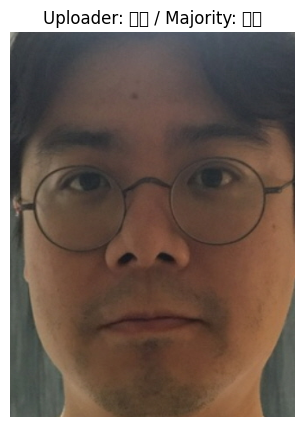

Uploader : 기쁨
Annot A  : 중립
Annot B  : 중립
Annot C  : 중립
Majority : 중립
--------------------------------------------------


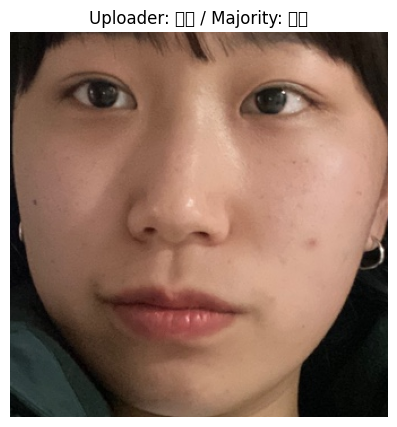

Uploader : 기쁨
Annot A  : 중립
Annot B  : 중립
Annot C  : 중립
Majority : 중립
--------------------------------------------------


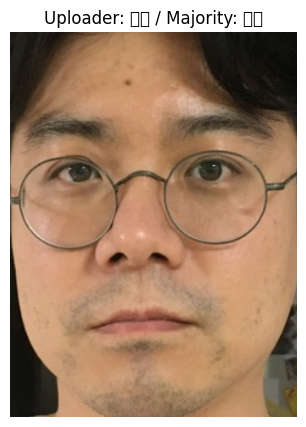

Uploader : 기쁨
Annot A  : 중립
Annot B  : 중립
Annot C  : 중립
Majority : 중립
--------------------------------------------------


In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 업로더와 다수결 라벨이 다른 이미지들을 하나씩 확인
for _, row in majority_disagree_df.iterrows():

    # DataFrame에 저장된 실제 이미지 경로
    image_path = Path(row['image_path'])

    # 한글 경로에서도 이미지를 읽을 수 있도록
    # np.fromfile() + cv2.imdecode() 사용
    image_array = np.fromfile(
        str(image_path),
        dtype=np.uint8
    )

    image = cv2.imdecode(
        image_array,
        cv2.IMREAD_COLOR
    )

    # OpenCV의 BGR 이미지를 Matplotlib용 RGB로 변환
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # annot_A의 bounding box 좌표를 정수로 변환
    min_x = int(row['minX'])
    min_y = int(row['minY'])
    max_x = int(row['maxX'])
    max_y = int(row['maxY'])

    # 얼굴 영역만 crop
    face = image_rgb[
        min_y:max_y,
        min_x:max_x
    ]

    # 얼굴 이미지 출력
    plt.figure(figsize=(5, 5))
    plt.imshow(face)

    # 한글 폰트 경고를 피하기 위해 제목은 영문 key 중심으로 표시
    plt.title(
        f"Uploader: {row['faceExp_uploader']} / "
        f"Majority: {row['majority_label']}"
    )

    plt.axis('off')
    plt.show()

    # 각 어노테이터 판정도 함께 출력
    print("Uploader :", row['faceExp_uploader'])
    print("Annot A  :", row['annot_A_faceExp'])
    print("Annot B  :", row['annot_B_faceExp'])
    print("Annot C  :", row['annot_C_faceExp'])
    print("Majority :", row['majority_label'])
    print("-" * 50)

### 불일치 이미지 시각적 확인 결과

업로더 감정과 어노테이터 다수결 감정이 다른 3장의 이미지를 직접 확인하였다.

세 이미지 모두 업로더 감정은 `기쁨`으로 기록되어 있었지만,
annot_A, annot_B, annot_C는 모두 `중립`으로 판정하였다.

실제 얼굴 이미지를 확인한 결과,
뚜렷한 미소나 기쁨 표정이 나타나지 않고 비교적 무표정에 가까운 모습이어서
어노테이터의 `중립` 판정이 시각적으로 더 자연스럽게 보였다.

따라서 본 데이터 학습 시에는 업로더 감정을 그대로 사용하는 것보다,
여러 어노테이터의 판정 결과를 함께 고려하여 최종 라벨을 결정하는 방법이
더 적절할 가능성이 있다고 판단하였다.

다만 현재 결과는 샘플 데이터에 대한 확인이므로,
본 데이터에서도 동일한 기준이 적절한지는 추가 검증이 필요하다.

## 15. Bounding Box 품질 점검

샘플 이미지 389장을 대상으로 annot_A의 얼굴 bounding box 좌표가
정상적인 범위에 있는지 확인한다.

다음 항목을 점검한다.

- `minX < maxX`인지 확인
- `minY < maxY`인지 확인
- 얼굴 영역의 너비와 높이가 0보다 큰지 확인
- bounding box가 실제 이미지 크기를 벗어나는지 확인

이를 통해 향후 본 데이터에서도 bounding box를 이용한
얼굴 crop 전처리를 자동화할 수 있는지 검토한다.

In [55]:
# bounding box의 너비 계산
sample_df['bbox_width'] = (
    sample_df['maxX'] - sample_df['minX']
)

# bounding box의 높이 계산
sample_df['bbox_height'] = (
    sample_df['maxY'] - sample_df['minY']
)

# minX가 maxX보다 작은지 확인
sample_df['valid_x'] = (
    sample_df['minX'] < sample_df['maxX']
)

# minY가 maxY보다 작은지 확인
sample_df['valid_y'] = (
    sample_df['minY'] < sample_df['maxY']
)

# bounding box 너비와 높이가 모두 0보다 큰지 확인
sample_df['valid_bbox_size'] = (
    (sample_df['bbox_width'] > 0) &
    (sample_df['bbox_height'] > 0)
)

# 결과 확인
print("X 좌표 정상 여부")
print(sample_df['valid_x'].value_counts())

print("\nY 좌표 정상 여부")
print(sample_df['valid_y'].value_counts())

print("\nBounding Box 크기 정상 여부")
print(sample_df['valid_bbox_size'].value_counts())

X 좌표 정상 여부
valid_x
True    389
Name: count, dtype: int64

Y 좌표 정상 여부
valid_y
True    389
Name: count, dtype: int64

Bounding Box 크기 정상 여부
valid_bbox_size
True    389
Name: count, dtype: int64


In [56]:
# 각 이미지의 실제 크기를 저장할 리스트
image_widths = []
image_heights = []

# 이미지 로딩 성공 여부 저장
image_load_ok = []

for image_path_str in sample_df['image_path']:

    # 문자열 경로를 Path 객체로 변환
    image_path = Path(image_path_str)

    # 한글 경로에서도 이미지가 열리도록 바이너리로 읽기
    image_array = np.fromfile(
        str(image_path),
        dtype=np.uint8
    )

    # OpenCV 이미지로 디코딩
    image = cv2.imdecode(
        image_array,
        cv2.IMREAD_COLOR
    )

    # 이미지 로딩에 실패한 경우
    if image is None:
        image_widths.append(None)
        image_heights.append(None)
        image_load_ok.append(False)

    # 정상적으로 로딩된 경우
    else:
        height, width = image.shape[:2]

        image_widths.append(width)
        image_heights.append(height)
        image_load_ok.append(True)


# DataFrame에 실제 이미지 크기 저장
sample_df['image_width'] = image_widths
sample_df['image_height'] = image_heights

# 이미지 로딩 성공 여부 저장
sample_df['image_load_ok'] = image_load_ok

In [57]:
# 이미지가 정상적으로 로딩된 개수 확인
sample_df['image_load_ok'].value_counts()

image_load_ok
True    389
Name: count, dtype: int64

In [58]:
# bounding box가 이미지 내부에 있는지 확인
sample_df['bbox_inside_image'] = (
    (sample_df['minX'] >= 0) &
    (sample_df['minY'] >= 0) &
    (sample_df['maxX'] <= sample_df['image_width']) &
    (sample_df['maxY'] <= sample_df['image_height'])
)

# 결과 확인
sample_df['bbox_inside_image'].value_counts()

bbox_inside_image
True    389
Name: count, dtype: int64

In [59]:
# 좌표 또는 크기에 문제가 있는 bounding box 확인
invalid_bbox_df = sample_df[
    (~sample_df['valid_bbox_size']) |
    (~sample_df['bbox_inside_image'])
]

invalid_bbox_df[
    [
        'filename',
        'minX',
        'minY',
        'maxX',
        'maxY',
        'bbox_width',
        'bbox_height',
        'image_width',
        'image_height'
    ]
]

,filename,minX,minY,maxX,maxY,bbox_width,bbox_height,image_width,image_height


In [60]:
# 얼굴 bounding box 너비와 높이에 대한 기초 통계 확인
sample_df[
    ['bbox_width', 'bbox_height']
].describe()

,bbox_width,bbox_height
count,389.000000,389.000000
mean,435.380268,566.866966
std,66.476833,83.391977
min,26.862920,38.968030
25%,405.571750,525.592530
50%,434.351810,567.099547
75%,458.777140,616.184980
max,735.376900,979.275300


### Bounding Box 품질 점검 결과

샘플 이미지 389장에 대해 annot_A의 bounding box 품질을 확인하였다.

- X 좌표 정상: 389장
- Y 좌표 정상: 389장
- Bounding Box 너비·높이 정상: 389장
- 이미지 로딩 성공: 389장
- Bounding Box가 이미지 내부에 존재: 389장

따라서 샘플 데이터에서는 annot_A의 bounding box를 이용하여
얼굴 영역을 자동으로 crop하는 데 구조적인 문제는 발견되지 않았다.

Bounding Box의 평균 너비는 약 435픽셀, 평균 높이는 약 567픽셀로
대부분 충분한 크기의 얼굴 영역을 가지고 있었다.

다만 Bounding Box의 최소 너비는 약 27픽셀, 최소 높이는 약 39픽셀로 나타나
일부 이미지에는 상대적으로 작은 얼굴 영역이 포함되어 있을 가능성이 있다.

따라서 본 데이터 전처리 시에는 매우 작은 얼굴 이미지가 존재하는지 추가로 확인하고,
모델 입력 크기로 resize할 때 발생할 수 있는 화질 저하를 고려할 필요가 있다.

## 16. 작은 Bounding Box 이미지 확인

Bounding Box의 너비 또는 높이가 100픽셀 미만인 이미지를 확인하였다.

샘플 이미지 389장 중 해당 조건에 해당하는 이미지는 1장이었으며,
해당 이미지의 Bounding Box 크기는 다음과 같았다.

- 너비: 약 27픽셀
- 높이: 약 39픽셀

대부분의 샘플 이미지는 충분한 크기의 얼굴 영역을 가지고 있었지만,
일부 이미지에는 매우 작은 얼굴 영역이 포함되어 있음을 확인하였다.

따라서 해당 이미지를 직접 확인하여
정상적으로 멀리 촬영된 얼굴인지, Bounding Box 오류인지 검토할 필요가 있다.

In [61]:
# 얼굴 영역이 너무 작은 샘플이 있는지 확인
small_bbox_df = sample_df[
    (sample_df['bbox_width'] < 100) |
    (sample_df['bbox_height'] < 100)
]

print("작은 Bounding Box 이미지 수:", len(small_bbox_df))

small_bbox_df[
    [
        'filename',
        'bbox_width',
        'bbox_height'
    ]
]

작은 Bounding Box 이미지 수: 1


,filename,bbox_width,bbox_height
208,0cebc58b878df61c71de8e92bf181af059fe272b432e0f...,26.86292,38.96803


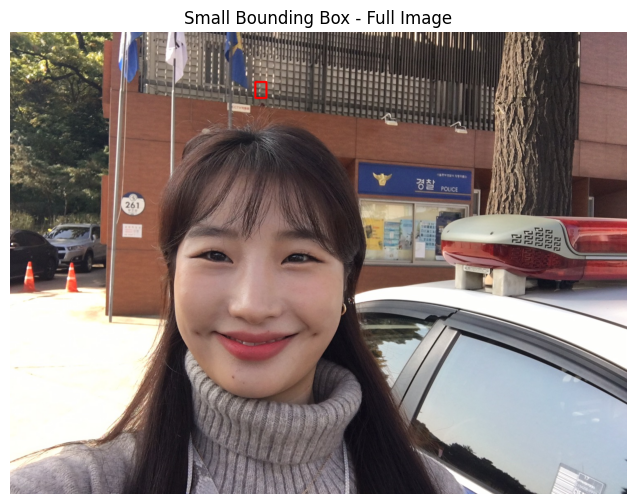

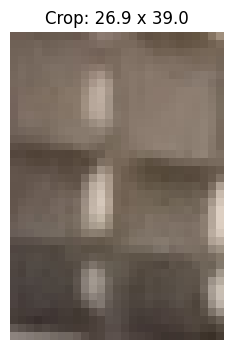

In [62]:
# 작은 Bounding Box 이미지 1장 가져오기
row = small_bbox_df.iloc[0]

# 실제 이미지 경로
image_path = Path(row['image_path'])

# 한글 경로 이미지 로딩
image_array = np.fromfile(
    str(image_path),
    dtype=np.uint8
)

image = cv2.imdecode(
    image_array,
    cv2.IMREAD_COLOR
)

# BGR → RGB 변환
image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

# Bounding Box 좌표 가져오기
min_x = int(row['minX'])
min_y = int(row['minY'])
max_x = int(row['maxX'])
max_y = int(row['maxY'])

# Bounding Box가 표시된 전체 이미지 생성
image_box = image_rgb.copy()

cv2.rectangle(
    image_box,
    (min_x, min_y),
    (max_x, max_y),
    (255, 0, 0),
    3
)

# 얼굴 영역 crop
face = image_rgb[
    min_y:max_y,
    min_x:max_x
]

# 전체 이미지 확인
plt.figure(figsize=(8, 6))
plt.imshow(image_box)
plt.title("Small Bounding Box - Full Image")
plt.axis('off')
plt.show()

# Crop된 얼굴 확인
plt.figure(figsize=(4, 4))
plt.imshow(face)
plt.title(
    f"Crop: {row['bbox_width']:.1f} x "
    f"{row['bbox_height']:.1f}"
)
plt.axis('off')
plt.show()

### 작은 Bounding Box 이미지 확인 결과

Bounding Box의 너비 또는 높이가 100픽셀 미만인 1장의 이미지를
직접 시각적으로 확인하였다.

원본 이미지에서는 얼굴이 크게 촬영되어 있었으나,
annot_A의 Bounding Box는 실제 얼굴이 아닌
머리 위 배경의 작은 영역을 가리키고 있었다.

따라서 해당 사례는 얼굴 자체가 작은 이미지가 아니라
Bounding Box 어노테이션 오류로 판단된다.

좌표 범위 검사만으로는 이러한 오류를 발견하기 어려우므로,
annot_B와 annot_C의 Bounding Box를 추가로 비교하여
대체 가능한 정상 좌표가 존재하는지 확인할 필요가 있다.

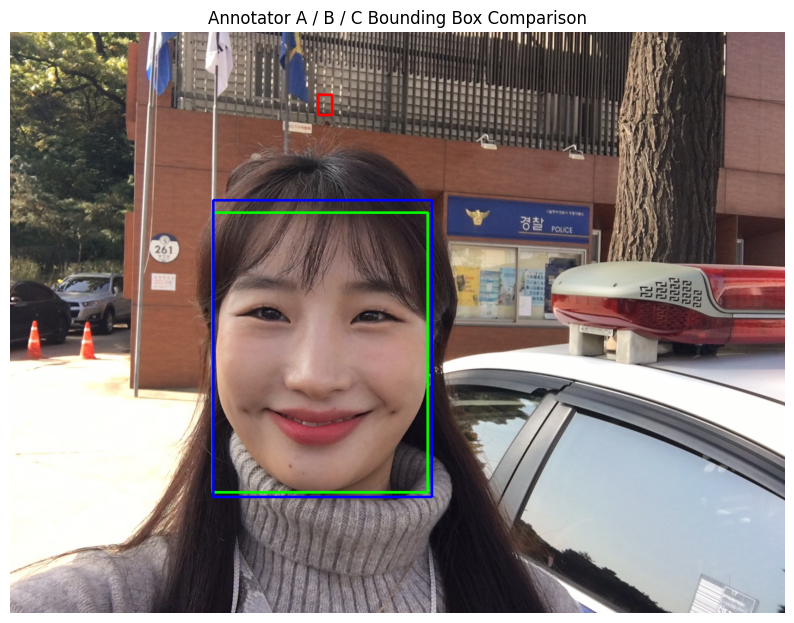

A width: 26.862920000000145 height: 38.96802999999997
B width: 416.13871524046954 height: 540.7107546185159
C width: 422.7427675119521 height: 573.7749000000001


In [63]:
# 작은 Bounding Box 문제가 발견된 이미지의 원본 JSON 정보 가져오기
filename = row['filename']
label_info = label_dict[filename]

# 원본 이미지 복사
image_compare = image_rgb.copy()

# 어노테이터별 Bounding Box 가져오기
boxes = {
    'A': label_info['annot_A']['boxes'],
    'B': label_info['annot_B']['boxes'],
    'C': label_info['annot_C']['boxes']
}

# 비교를 위해 색상 지정
colors = {
    'A': (255, 0, 0),   # 빨강
    'B': (0, 255, 0),   # 초록
    'C': (0, 0, 255)    # 파랑
}

# A/B/C Bounding Box를 같은 이미지 위에 표시
for annotator, box in boxes.items():

    min_x = int(box['minX'])
    min_y = int(box['minY'])
    max_x = int(box['maxX'])
    max_y = int(box['maxY'])

    cv2.rectangle(
        image_compare,
        (min_x, min_y),
        (max_x, max_y),
        colors[annotator],
        4
    )

# 결과 출력
plt.figure(figsize=(10, 8))
plt.imshow(image_compare)
plt.title("Annotator A / B / C Bounding Box Comparison")
plt.axis('off')
plt.show()

# 좌표도 함께 확인
for annotator, box in boxes.items():
    print(
        annotator,
        "width:",
        box['maxX'] - box['minX'],
        "height:",
        box['maxY'] - box['minY']
    )

### 어노테이터별 Bounding Box 비교 결과

작은 Bounding Box가 발견된 이미지를 대상으로
annot_A, annot_B, annot_C의 Bounding Box를 비교하였다.

그 결과,

- annot_A: 약 27 × 39 픽셀
- annot_B: 약 416 × 541 픽셀
- annot_C: 약 423 × 574 픽셀

로 나타났다.

시각적으로 확인한 결과 annot_A의 Bounding Box는
실제 얼굴이 아닌 머리 위의 배경 영역을 잘못 표시하고 있었으며,
annot_B와 annot_C는 실제 얼굴 영역을 정상적으로 표시하였다.

따라서 하나의 어노테이터 Bounding Box만 고정적으로 사용하는 경우
일부 어노테이션 오류가 얼굴 crop 결과에 그대로 반영될 수 있음을 확인하였다.

향후 본 데이터 전처리에서는 세 어노테이터의 Bounding Box를 함께 비교하여
이상치를 줄일 수 있는 대표 Bounding Box 결정 방법을 검토할 필요가 있다.

## 17. 어노테이터 Bounding Box 중앙값 검토

일부 이미지에서 특정 어노테이터의 Bounding Box가
실제 얼굴 위치와 크게 다른 오류가 발견되었다.

따라서 annot_A, annot_B, annot_C의 각 Bounding Box 좌표에 대해
중앙값(median)을 계산하여 대표 Bounding Box로 사용할 수 있는지 검토한다.

중앙값은 세 값 중 가운데 값을 사용하므로,
특정 어노테이터의 좌표가 크게 벗어난 경우
평균보다 이상치의 영향을 적게 받을 수 있다.

In [64]:
# 문제가 발견된 이미지의 JSON 정보 가져오기
filename = row['filename']
label_info = label_dict[filename]

# 세 어노테이터의 Bounding Box
box_a = label_info['annot_A']['boxes']
box_b = label_info['annot_B']['boxes']
box_c = label_info['annot_C']['boxes']


# 좌표별 중앙값 계산
median_min_x = np.median([
    box_a['minX'],
    box_b['minX'],
    box_c['minX']
])

median_min_y = np.median([
    box_a['minY'],
    box_b['minY'],
    box_c['minY']
])

median_max_x = np.median([
    box_a['maxX'],
    box_b['maxX'],
    box_c['maxX']
])

median_max_y = np.median([
    box_a['maxY'],
    box_b['maxY'],
    box_c['maxY']
])


# 계산된 중앙값 Bounding Box 확인
print("Median Bounding Box")
print("minX:", median_min_x)
print("minY:", median_min_y)
print("maxX:", median_max_x)
print("maxY:", median_max_y)

print(
    "width:",
    median_max_x - median_min_x
)

print(
    "height:",
    median_max_y - median_min_y
)

Median Bounding Box
minX: 393.608723435625
minY: 325.63229999999993
maxX: 808.2336379364405
maxY: 890.6498308665704
width: 414.62491450081546
height: 565.0175308665705


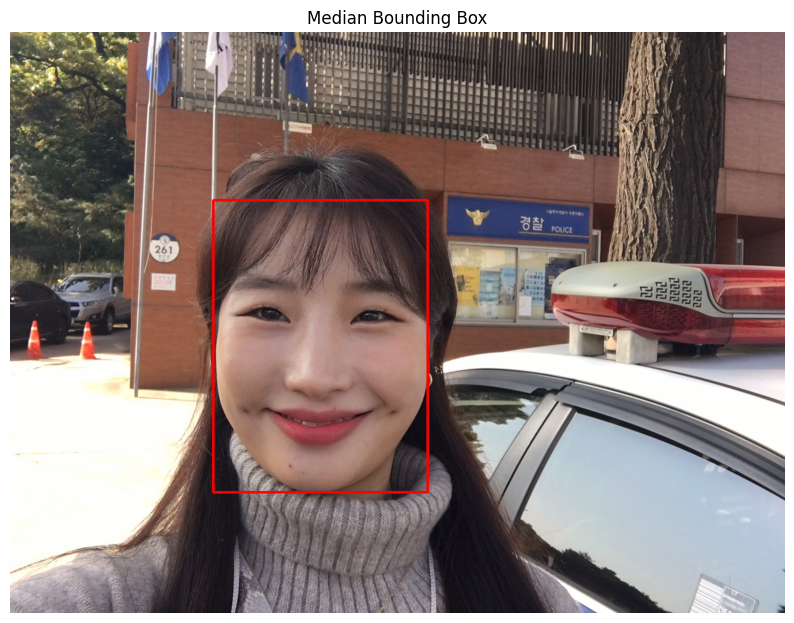

In [65]:
# 중앙값 Bounding Box를 그리기 위한 이미지 복사
image_median = image_rgb.copy()

# 좌표를 정수로 변환
x1 = int(median_min_x)
y1 = int(median_min_y)
x2 = int(median_max_x)
y2 = int(median_max_y)

# 중앙값 Bounding Box 표시
cv2.rectangle(
    image_median,
    (x1, y1),
    (x2, y2),
    (255, 0, 0),
    4
)

# 결과 확인
plt.figure(figsize=(10, 8))
plt.imshow(image_median)
plt.title("Median Bounding Box")
plt.axis('off')
plt.show()

### 중앙값 Bounding Box 적용 결과

Bounding Box 오류가 확인된 이미지에 대해
annot_A, annot_B, annot_C의 좌표별 중앙값을 이용하여
대표 Bounding Box를 생성하였다.

중앙값 Bounding Box의 크기는 약

- 너비: 415픽셀
- 높이: 565픽셀

로 나타났다.

시각적으로 확인한 결과,
중앙값 Bounding Box는 실제 얼굴 영역을 정상적으로 포함하였다.

특정 어노테이터의 Bounding Box가 크게 잘못된 경우에도
세 어노테이터 좌표의 중앙값을 사용하면 이상치의 영향을 줄일 수 있음을 확인하였다.

따라서 본 데이터 전처리에서는 하나의 어노테이터 좌표를 고정적으로 사용하는 방식보다,
annot_A, annot_B, annot_C의 좌표 중앙값을 대표 Bounding Box로 사용하는 방안을
우선적으로 검토한다.

## 18. 전체 샘플에 중앙값 Bounding Box 적용

In [66]:
# 각 이미지의 annot_A/B/C Bounding Box 좌표를 이용해
# 좌표별 중앙값을 저장할 리스트 생성
median_min_x_list = []
median_min_y_list = []
median_max_x_list = []
median_max_y_list = []


# 실제 샘플 이미지와 매칭된 JSON 데이터를 순회
for item in matched_data:

    # 세 어노테이터의 Bounding Box 가져오기
    box_a = item['annot_A']['boxes']
    box_b = item['annot_B']['boxes']
    box_c = item['annot_C']['boxes']

    # minX 중앙값
    median_min_x_list.append(
        np.median([
            box_a['minX'],
            box_b['minX'],
            box_c['minX']
        ])
    )

    # minY 중앙값
    median_min_y_list.append(
        np.median([
            box_a['minY'],
            box_b['minY'],
            box_c['minY']
        ])
    )

    # maxX 중앙값
    median_max_x_list.append(
        np.median([
            box_a['maxX'],
            box_b['maxX'],
            box_c['maxX']
        ])
    )

    # maxY 중앙값
    median_max_y_list.append(
        np.median([
            box_a['maxY'],
            box_b['maxY'],
            box_c['maxY']
        ])
    )


# DataFrame에 중앙값 Bounding Box 좌표 추가
sample_df['median_minX'] = median_min_x_list
sample_df['median_minY'] = median_min_y_list
sample_df['median_maxX'] = median_max_x_list
sample_df['median_maxY'] = median_max_y_list

In [67]:
# 중앙값 Bounding Box의 너비 계산
sample_df['median_bbox_width'] = (
    sample_df['median_maxX']
    - sample_df['median_minX']
)

# 중앙값 Bounding Box의 높이 계산
sample_df['median_bbox_height'] = (
    sample_df['median_maxY']
    - sample_df['median_minY']
)

In [68]:
sample_df[
    [
        'median_bbox_width',
        'median_bbox_height'
    ]
].describe()

,median_bbox_width,median_bbox_height
count,389.000000,389.000000
mean,433.955378,572.298246
std,62.270460,78.549180
min,165.326473,225.823875
25%,405.396300,531.918640
50%,428.628000,570.872190
75%,456.658075,615.138890
max,735.376900,1021.380315


In [69]:
# 중앙값 Bounding Box 기준으로
# 너비 또는 높이가 100픽셀 미만인 이미지 확인
small_median_bbox_df = sample_df[
    (sample_df['median_bbox_width'] < 100) |
    (sample_df['median_bbox_height'] < 100)
]

print(
    "중앙값 기준 작은 Bounding Box 이미지 수:",
    len(small_median_bbox_df)
)

small_median_bbox_df[
    [
        'filename',
        'median_bbox_width',
        'median_bbox_height'
    ]
]

중앙값 기준 작은 Bounding Box 이미지 수: 0


,filename,median_bbox_width,median_bbox_height


## 19. 중앙값 Bounding Box 좌표 유효성 검증

전체 샘플 이미지 389장에 적용한 중앙값 Bounding Box가
실제 이미지 내부에 정상적으로 위치하는지 확인한다.

다음 조건을 점검한다.

- `median_minX >= 0`
- `median_minY >= 0`
- `median_maxX <= image_width`
- `median_maxY <= image_height`
- Bounding Box의 너비와 높이가 0보다 큰지 확인

이를 통해 중앙값 Bounding Box를
향후 얼굴 crop 전처리에 사용할 수 있는지 최종 검토한다.

In [70]:
# 중앙값 Bounding Box의 좌표 순서가 정상인지 확인
sample_df['median_valid_bbox'] = (
    (sample_df['median_minX'] < sample_df['median_maxX']) &
    (sample_df['median_minY'] < sample_df['median_maxY'])
)

# 중앙값 Bounding Box가 실제 이미지 영역 안에 있는지 확인
sample_df['median_bbox_inside_image'] = (
    (sample_df['median_minX'] >= 0) &
    (sample_df['median_minY'] >= 0) &
    (sample_df['median_maxX'] <= sample_df['image_width']) &
    (sample_df['median_maxY'] <= sample_df['image_height'])
)

# 결과 확인
print("중앙값 Bounding Box 좌표 정상 여부")
print(sample_df['median_valid_bbox'].value_counts())

print("\n중앙값 Bounding Box 이미지 내부 존재 여부")
print(sample_df['median_bbox_inside_image'].value_counts())

중앙값 Bounding Box 좌표 정상 여부
median_valid_bbox
True    389
Name: count, dtype: int64

중앙값 Bounding Box 이미지 내부 존재 여부
median_bbox_inside_image
True    389
Name: count, dtype: int64


In [71]:
# 중앙값 Bounding Box에 문제가 있는 데이터만 추출
invalid_median_bbox_df = sample_df[
    (~sample_df['median_valid_bbox']) |
    (~sample_df['median_bbox_inside_image'])
]

print(
    "중앙값 Bounding Box 이상 이미지 수:",
    len(invalid_median_bbox_df)
)

invalid_median_bbox_df[
    [
        'filename',
        'median_minX',
        'median_minY',
        'median_maxX',
        'median_maxY',
        'median_bbox_width',
        'median_bbox_height',
        'image_width',
        'image_height'
    ]
]

중앙값 Bounding Box 이상 이미지 수: 0


,filename,median_minX,median_minY,median_maxX,median_maxY,median_bbox_width,median_bbox_height,image_width,image_height


## 20. 중앙값 Bounding Box를 이용한 전체 얼굴 Crop 검증

전체 샘플 이미지 389장에 대해
annot_A, annot_B, annot_C의 좌표 중앙값으로 생성한 Bounding Box를 사용하여
얼굴 영역을 자동으로 crop한다.

모든 이미지에서 얼굴 crop이 정상적으로 수행되는지 확인하고,
향후 본 데이터 전처리 자동화에 사용할 수 있는지 검토한다.

In [72]:
def load_image_unicode(image_path):
    """
    한글 경로가 포함된 이미지 파일을 OpenCV 형식으로 불러오는 함수
    """

    # 이미지 파일을 바이너리 배열로 읽기
    image_array = np.fromfile(
        str(image_path),
        dtype=np.uint8
    )

    # 바이너리 배열을 OpenCV 이미지로 디코딩
    image = cv2.imdecode(
        image_array,
        cv2.IMREAD_COLOR
    )

    return image

In [73]:
def crop_face_with_median_bbox(row):
    """
    DataFrame 한 행의 중앙값 Bounding Box를 이용해
    얼굴 영역을 crop하는 함수
    """

    # 이미지 경로 가져오기
    image_path = Path(row['image_path'])

    # 한글 경로 대응 방식으로 이미지 로드
    image = load_image_unicode(image_path)

    # 이미지 로딩 실패 시 None 반환
    if image is None:
        return None

    # 중앙값 Bounding Box 좌표를 정수형으로 변환
    x1 = int(row['median_minX'])
    y1 = int(row['median_minY'])
    x2 = int(row['median_maxX'])
    y2 = int(row['median_maxY'])

    # 얼굴 영역 crop
    face = image[
        y1:y2,
        x1:x2
    ]

    # crop된 영역이 비어 있으면 None 반환
    if face.size == 0:
        return None

    return face

In [74]:
# 얼굴 crop 성공 여부를 저장할 리스트
crop_success = []

# crop된 얼굴의 너비와 높이를 저장할 리스트
crop_widths = []
crop_heights = []


# DataFrame의 각 이미지에 대해 얼굴 crop 실행
for _, row in sample_df.iterrows():

    face = crop_face_with_median_bbox(row)

    # crop 실패
    if face is None:
        crop_success.append(False)
        crop_widths.append(None)
        crop_heights.append(None)

    # crop 성공
    else:
        height, width = face.shape[:2]

        crop_success.append(True)
        crop_widths.append(width)
        crop_heights.append(height)


# 결과를 DataFrame에 저장
sample_df['crop_success'] = crop_success
sample_df['crop_width'] = crop_widths
sample_df['crop_height'] = crop_heights

In [75]:
# 전체 얼굴 crop 성공 여부 확인
sample_df['crop_success'].value_counts()

crop_success
True    389
Name: count, dtype: int64

In [76]:
sample_df[
    [
        'crop_width',
        'crop_height'
    ]
].describe()

,crop_width,crop_height
count,389.000000,389.000000
mean,433.951157,572.269923
std,62.246974,78.552082
min,165.000000,226.000000
25%,405.000000,532.000000
50%,429.000000,571.000000
75%,456.000000,615.000000
max,735.000000,1022.000000


In [77]:
# 얼굴 crop에 실패한 이미지 확인
crop_failed_df = sample_df[
    ~sample_df['crop_success']
]

print(
    "얼굴 Crop 실패 이미지 수:",
    len(crop_failed_df)
)

crop_failed_df[
    [
        'filename',
        'image_path',
        'median_minX',
        'median_minY',
        'median_maxX',
        'median_maxY'
    ]
]

얼굴 Crop 실패 이미지 수: 0


,filename,image_path,median_minX,median_minY,median_maxX,median_maxY


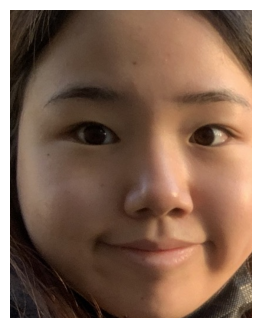

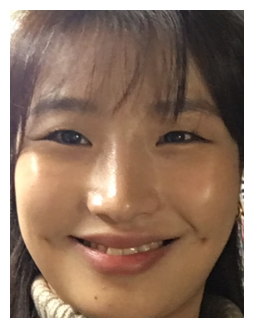

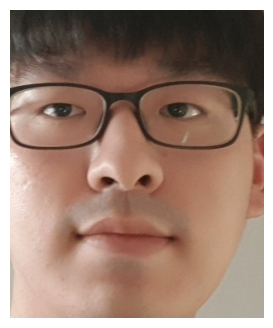

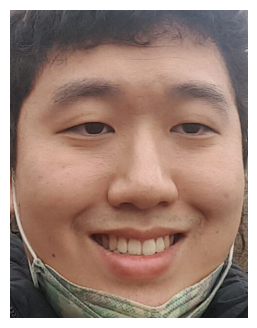

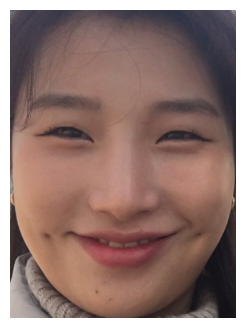

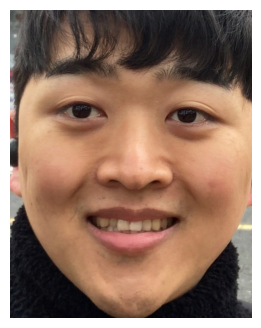

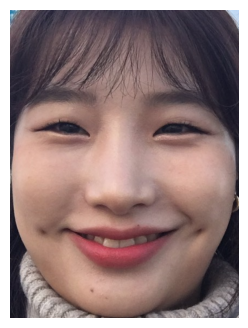

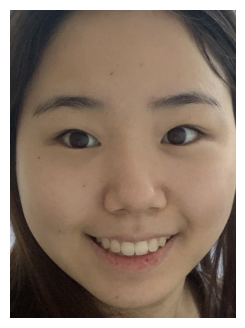

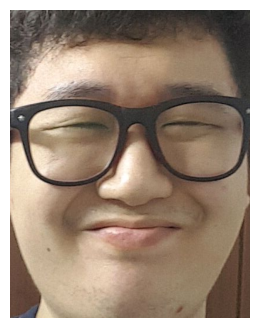

In [78]:
# 전체 샘플 중 9장을 임의로 선택
sample_rows = sample_df.sample(
    n=9,
    random_state=42
)

for _, row in sample_rows.iterrows():

    face = crop_face_with_median_bbox(row)

    # crop 실패 시 건너뜀
    if face is None:
        continue

    # OpenCV BGR → RGB 변환
    face_rgb = cv2.cvtColor(
        face,
        cv2.COLOR_BGR2RGB
    )

    # crop 결과 출력
    plt.figure(figsize=(4, 4))
    plt.imshow(face_rgb)
    plt.axis('off')
    plt.show()

### 전체 얼굴 Crop 검증 결과

중앙값 Bounding Box를 이용하여 샘플 이미지 389장의 얼굴 영역을
자동으로 crop하였다.

그 결과,

- 얼굴 Crop 성공: 389장
- 얼굴 Crop 실패: 0장

으로 모든 샘플 이미지에서 얼굴 영역을 정상적으로 추출할 수 있었다.

Crop된 얼굴의 평균 크기는 약

- 너비: 434픽셀
- 높이: 572픽셀

로 나타났으며, 중앙값 Bounding Box의 크기 통계와 거의 동일하였다.

Bounding Box 좌표는 실수형이지만 실제 이미지 Crop 시에는
픽셀 인덱스로 사용하기 위해 정수형으로 변환하므로,
Bounding Box 통계와 Crop 크기 사이에 소수 수준의 작은 차이가 발생할 수 있다.

또한 임의의 샘플 이미지를 시각적으로 확인한 결과
얼굴 영역이 정상적으로 추출되는 것을 확인하였다.

따라서 샘플 데이터 기준으로
세 어노테이터의 Bounding Box 좌표 중앙값을 이용한
얼굴 Crop 전처리 방법을 적용할 수 있음을 확인하였다.

## 21. 샘플 데이터 검증 최종 정리

AI-Hub 「한국인 감정인식을 위한 복합 영상」의 기쁨 클래스 샘플 데이터를 이용하여
JSON 구조, 이미지 매칭, 감정 라벨, 얼굴 Bounding Box, 얼굴 Crop 전처리 가능 여부를 확인하였다.

### 1. JSON 및 이미지 매칭

기쁨 클래스 라벨링 JSON에는 총 60,103건의 정보가 포함되어 있었으며,
샘플 원천 이미지는 389장이었다.

파일명을 기준으로 비교한 결과,

- JSON 데이터 수: 60,103건
- 샘플 원천 이미지 수: 389장
- JSON과 일치하는 이미지 수: 389장
- 이미지에만 존재하는 파일: 0장

으로 확인되었다.

따라서 샘플 원천 이미지 389장은 모두 JSON 라벨링 정보와 정상적으로 연결되었다.


### 2. 감정 라벨 일치 여부

annot_A, annot_B, annot_C의 감정 판정을 비교한 결과,

- 세 어노테이터 모두 일치: 378장
- 어노테이터 간 불일치: 11장

으로 나타났다.

또한 업로더 감정과 annot_A의 감정을 비교한 결과,

- 일치: 380장
- 불일치: 9장

이었다.

세 어노테이터의 감정 판정을 다수결 방식으로 통합한 뒤
업로더 감정과 비교한 결과,

- 업로더 감정과 다수결 라벨 일치: 386장
- 불일치: 3장

으로 나타났다.

불일치한 3장의 이미지를 직접 확인한 결과,
업로더는 모두 `기쁨`으로 기록하였으나
annot_A, annot_B, annot_C는 모두 `중립`으로 판정하였다.

실제 이미지도 비교적 무표정에 가까운 모습으로 확인되어,
샘플 데이터에서는 어노테이터 다수결 라벨을
최종 감정 라벨 후보로 활용할 수 있을 것으로 판단하였다.

다만 현재 검증은 기쁨 클래스 샘플 데이터에 한정되므로,
본 데이터 및 다른 감정 클래스에서도 동일한 기준이 적절한지 추가 검증이 필요하다.


### 3. Bounding Box 품질 확인

초기에는 전처리 단순화를 위해 annot_A의 Bounding Box를
대표 좌표로 사용하는 방안을 검토하였다.

샘플 389장의 annot_A 좌표를 확인한 결과,

- X 좌표 정상: 389장
- Y 좌표 정상: 389장
- Bounding Box 크기 정상: 389장
- 이미지 로딩 성공: 389장
- Bounding Box가 이미지 내부에 존재: 389장

으로 좌표 자체에는 문제가 없었다.

그러나 너비 또는 높이가 100픽셀 미만인 Bounding Box를 확인한 결과
1장의 이상 사례가 발견되었다.

해당 이미지를 직접 확인한 결과,
실제 얼굴은 이미지에서 크게 촬영되어 있었지만
annot_A의 Bounding Box는 얼굴이 아닌 배경의 작은 영역을 가리키고 있었다.

반면 annot_B와 annot_C의 Bounding Box는 정상적으로 얼굴 영역을 표시하였다.

따라서 좌표 범위가 정상이라는 사실만으로
Bounding Box가 실제 얼굴을 정확하게 표시한다고 판단할 수 없음을 확인하였다.


### 4. 중앙값 Bounding Box 적용

특정 어노테이터의 Bounding Box 오류 영향을 줄이기 위해
annot_A, annot_B, annot_C의 각 좌표에 대해 중앙값(median)을 계산하였다.

오류가 발견된 이미지에 중앙값 Bounding Box를 적용한 결과,
실제 얼굴 영역을 정상적으로 포함하는 것을 확인하였다.

이후 전체 샘플 389장에 중앙값 Bounding Box를 적용하였다.

중앙값 Bounding Box의 평균 크기는 약

- 평균 너비: 434픽셀
- 평균 높이: 572픽셀

로 나타났다.

또한 중앙값 기준으로 너비 또는 높이가 100픽셀 미만인 이미지는
0장으로 확인되었다.

중앙값 Bounding Box의 좌표 유효성과 이미지 내부 존재 여부를 확인한 결과,
389장 모두 정상적인 범위에 있었다.


### 5. 얼굴 Crop 자동화 검증

중앙값 Bounding Box를 이용하여
전체 샘플 이미지 389장의 얼굴 영역을 자동으로 Crop하였다.

그 결과,

- 얼굴 Crop 성공: 389장
- 얼굴 Crop 실패: 0장

으로 모든 샘플 이미지에서 얼굴 영역을 추출할 수 있었다.

Crop된 얼굴의 평균 크기는 약

- 평균 너비: 434픽셀
- 평균 높이: 572픽셀

로 나타났으며,
중앙값 Bounding Box의 크기 통계와 거의 동일하였다.

또한 임의의 샘플 이미지를 시각적으로 확인한 결과
얼굴 영역이 정상적으로 추출되는 것을 확인하였다.


### 최종 결론

기쁨 클래스 샘플 데이터를 이용한 사전 검증 결과,
JSON 라벨링 정보와 실제 이미지의 연결 구조를 확인하였으며
Bounding Box를 이용한 얼굴 Crop 전처리가 가능한 것으로 나타났다.

샘플 데이터 기준으로 향후 본 데이터 전처리에서는 다음 방법을 우선 검토한다.

- 감정 라벨: annot_A, annot_B, annot_C의 다수결 결과 활용
- 얼굴 Bounding Box: annot_A, annot_B, annot_C 좌표의 중앙값 활용
- 이미지 로딩: 한글 경로 문제를 고려하여 `np.fromfile()` + `cv2.imdecode()` 방식 사용
- 얼굴 전처리: 중앙값 Bounding Box를 이용한 자동 Crop 적용

다만 이번 검증은 기쁨 클래스 샘플 389장에 대한 결과이므로,
본 데이터와 다른 감정 클래스에서도 동일한 전처리 기준이 안정적으로 적용되는지
추가 확인한 뒤 최종 전처리 방법을 확정할 예정이다.